# 1D Non-linear Poisson-Boltzmann Benchmark

This notebook solves the **full non-linear** Poisson-Boltzmann equation in 1D.

## Model

For a symmetric electrolyte, the non-linear PB equation is:

$$
\frac{d^2 \phi}{dx^2} = \kappa^2 \sinh\!\left(\frac{z e \phi}{k_B T}\right)
$$

where $\phi$ is electric potential, $z$ is ionic valence, and $\kappa^{-1}$ is the Debye length.

## When to use this notebook

- Moderate to high surface potential
- Cases where linear PB underestimates near-wall charge screening
- Validation of solver robustness for stronger nonlinearity

> Use this notebook to capture finite-potential effects that the linear model cannot represent.

## What to check in results

- Sharper near-wall gradients than linear PB
- Larger deviation from exponential decay as potential increases


In [1]:
import unxt
import quaxed.numpy as jnp

import matplotlib.pyplot as plt

In [2]:
from fdm_edl.edl import ElectricalDoubleLayer
from fdm_edl.edl.system import boltzmann_factor

from fdm_edl.test import NonLinearPoissonBoltzmann
from fdm_edl import _constants

In [3]:
# 0.01 M 1-1 electrolyte, T = 298 K, epsilon_r = 78.5
edl_obj = ElectricalDoubleLayer("input.json")
x = unxt.Quantity(jnp.linspace(0, 50.0, 500), unit="nm")
sigma = _constants.ELEMENTARY_CHARGE / unxt.Quantity(1e4, "angstrom^2")

non_linear_pb = NonLinearPoissonBoltzmann(edl_obj=edl_obj, x=x, sigma=sigma)

In [4]:
edl_obj.compute(x, non_linear_pb.phi[0])

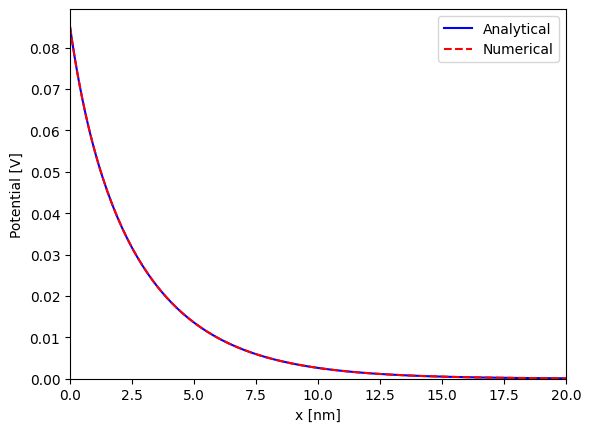

In [5]:
fig, ax = plt.subplots()

# potential in V
ax.plot(x.to("nm"), non_linear_pb.phi.to("V"), color="blue", label="Analytical")
ax.plot(
    x.to("nm"),
    edl_obj.result.solution.to("V"),
    color="red",
    linestyle="dashed",
    label="Numerical",
)
ax.legend()

ax.set_xlim(0, 20)
ax.set_ylim(bottom=0.0)
ax.set_xlabel("x [nm]")
ax.set_ylabel("Potential [V]")

plt.show()

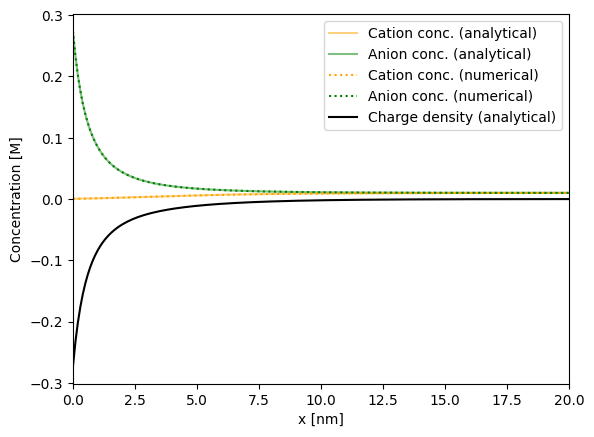

In [6]:
fig, ax = plt.subplots()

# Cache repeated values to avoid redundant conversion/lookups
x_nm = x.to("nm")
phi = non_linear_pb.phi
temperature = edl_obj.temperature
ion_profiles = edl_obj.get_ion_concentration_profiles()

# ion concentration in mol/L
c_cation = edl_obj.electrolyte.ions[0].molar_conc * boltzmann_factor(
    phi=phi,
    temperature=temperature,
    valency=1,
 )
c_anion = edl_obj.electrolyte.ions[1].molar_conc * boltzmann_factor(
    phi=phi,
    temperature=temperature,
    valency=-1,
 )

ax.plot(x_nm, c_cation, color="orange", label="Cation conc. (analytical)", alpha=0.5)
ax.plot(x_nm, c_anion, color="green", label="Anion conc. (analytical)", alpha=0.5)

ax.plot(
    x_nm,
    ion_profiles["Na"],
    ":",
    color="orange",
    label="Cation conc. (numerical)",
)
ax.plot(
    x_nm,
    ion_profiles["Cl"],
    ":",
    color="green",
    label="Anion conc. (numerical)",
)    

ax.plot(x_nm, c_cation - c_anion, color="k", label="Charge density (analytical)")

ax.set_xlim(0, 20)
ax.set_xlabel("x [nm]")
ax.set_ylabel("Concentration [M]")
ax.legend()

plt.show()